In [17]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataframes
awards_players_df = pd.read_csv('../datasets/awards_players.csv')
coaches_df = pd.read_csv('../datasets/coaches.csv')
players_teams_df = pd.read_csv('../datasets/players_teams.csv')
players_df = pd.read_csv('../datasets/players.csv')
series_post_df = pd.read_csv('../datasets/series_post.csv')
teams_post_df = pd.read_csv('../datasets/teams_post.csv')
teams_df = pd.read_csv('../datasets/teams.csv')


# Exploratory Data Analysis

## General Analysis

## Coaches Performance

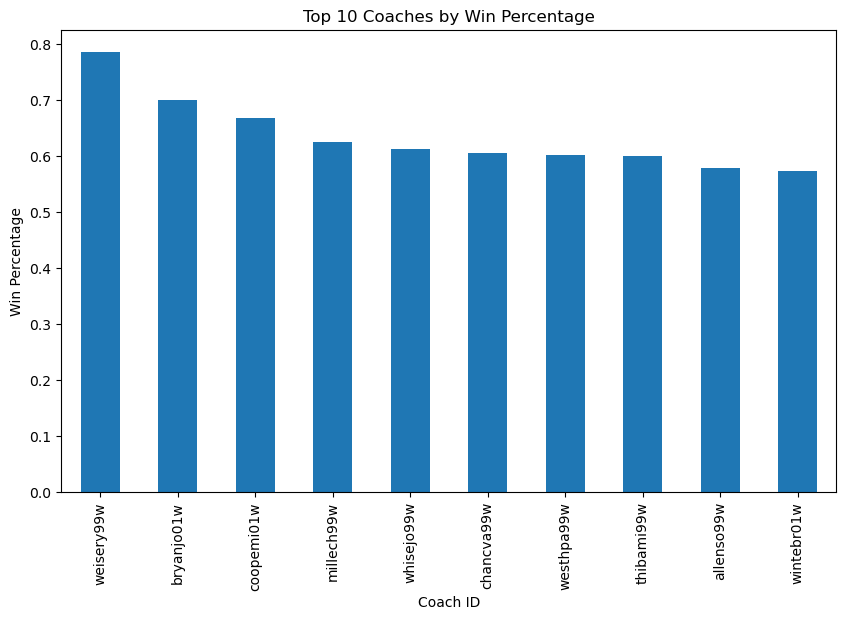

In [18]:
# Calculate win percentage for each coach
coaches_df['win_pct'] = coaches_df['won'] / (coaches_df['won'] + coaches_df['lost'])
top_coaches = coaches_df.groupby('coachID')['win_pct'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_coaches.plot(kind='bar')
plt.title('Top 10 Coaches by Win Percentage')
plt.ylabel('Win Percentage')
plt.xlabel('Coach ID')
plt.show()

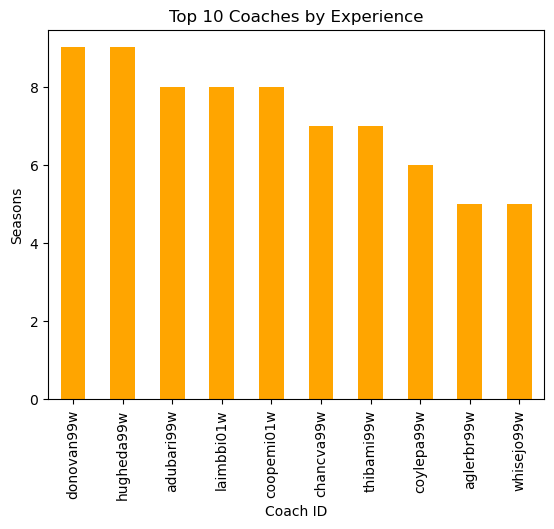

In [19]:
# Coaches with more experience (num of seasons coached)
coach_seasons = coaches_df.groupby('coachID')['year'].nunique().sort_values(ascending=False).head(10)
coach_seasons.plot(kind='bar', color='orange')
plt.title('Top 10 Coaches by Experience')
plt.xlabel('Coach ID')
plt.ylabel('Seasons')
plt.show()

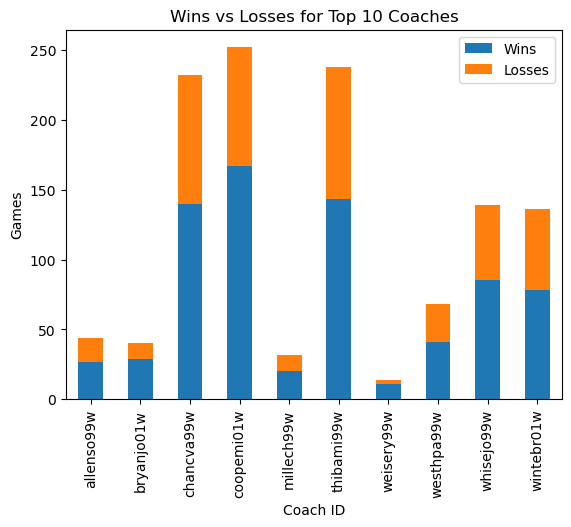

In [20]:
# Distribution of wins and losses for top coaches
top_coach_ids = top_coaches.index.tolist()
top_coach_stats = coaches_df[coaches_df['coachID'].isin(top_coach_ids)].groupby('coachID')[['won', 'lost']].sum()

top_coach_stats.plot(kind='bar', stacked=True)

plt.title('Wins vs Losses for Top 10 Coaches')
plt.xlabel('Coach ID')
plt.ylabel('Games')
plt.legend(['Wins', 'Losses'])
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_10884\1052409882.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coach_win_pct = coaches_df.groupby('coachID').apply(lambda x: x['won'].sum() / (x['won'].sum() + x['lost'].sum()))


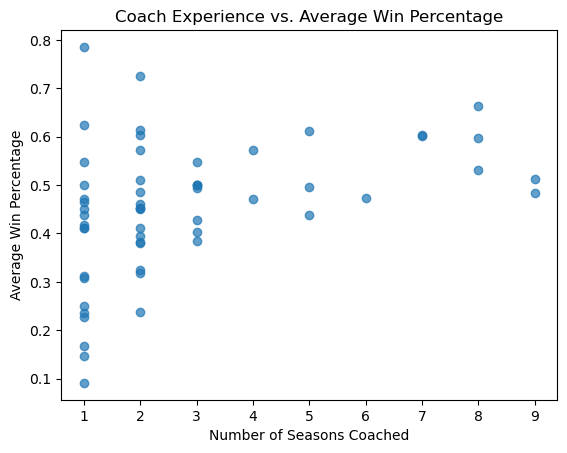

In [21]:
# Coach experience vs. average win percentage
coach_experience = coaches_df.groupby('coachID')['year'].nunique()
coach_win_pct = coaches_df.groupby('coachID').apply(lambda x: x['won'].sum() / (x['won'].sum() + x['lost'].sum()))

plt.scatter(coach_experience, coach_win_pct, alpha=0.7)
plt.title('Coach Experience vs. Average Win Percentage')
plt.xlabel('Number of Seasons Coached')
plt.ylabel('Average Win Percentage')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_10884\3547126606.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coach_win_pct = coaches_df.groupby('coachID').apply(lambda x: x['won'].sum() / (x['won'].sum() + x['lost'].sum()))


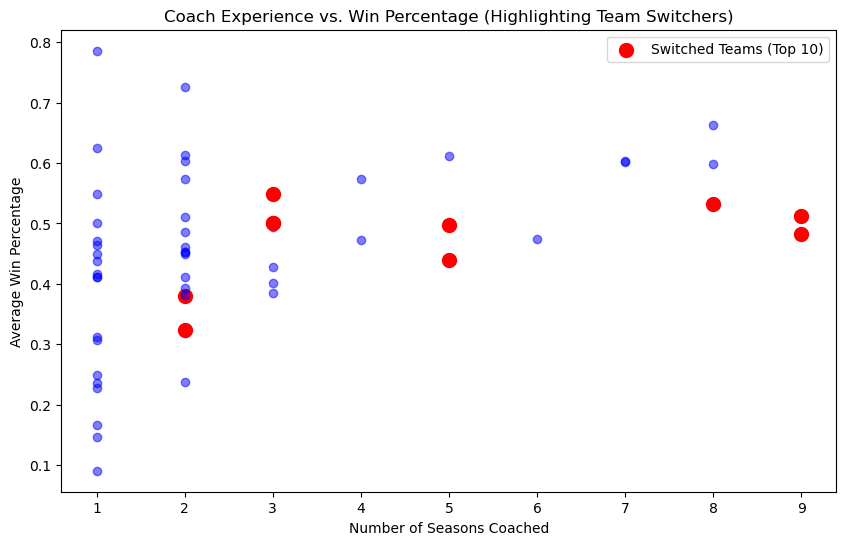

In [22]:
# Count number of unique teams coached by each coach using the full dataset
coach_team_switches = coaches_df.groupby('coachID')['tmID'].nunique()

# Find the top 10 coaches who switched teams the most
most_switches = coach_team_switches.sort_values(ascending=False).head(10).index

# Prepare experience and win percentage for all coaches
coach_experience = coaches_df.groupby('coachID')['year'].nunique()
coach_win_pct = coaches_df.groupby('coachID').apply(lambda x: x['won'].sum() / (x['won'].sum() + x['lost'].sum()))

# Scatter plot highlighting coaches who switched teams the most
plt.figure(figsize=(10,6))
for coach in coach_experience.index:
    if coach in most_switches:
        plt.scatter(coach_experience[coach], coach_win_pct[coach], color='red', s=100, label='Switched Teams (Top 10)' if 'Switched Teams (Top 10)' not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.scatter(coach_experience[coach], coach_win_pct[coach], color='blue', alpha=0.5)

plt.title('Coach Experience vs. Win Percentage (Highlighting Team Switchers)')
plt.xlabel('Number of Seasons Coached')
plt.ylabel('Average Win Percentage')
plt.legend()
plt.show()

## Player Analysis

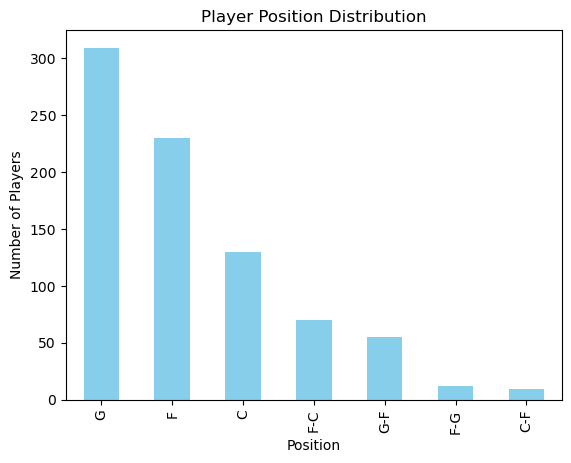

In [23]:
# Distribution of player positions
positions = players_df['pos'].value_counts()
positions.plot(kind='bar', color='skyblue')
plt.title('Player Position Distribution')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.show()

## Teams performance

year
1    256
2    256
3    256
4    238
5    221
Name: won, dtype: int64


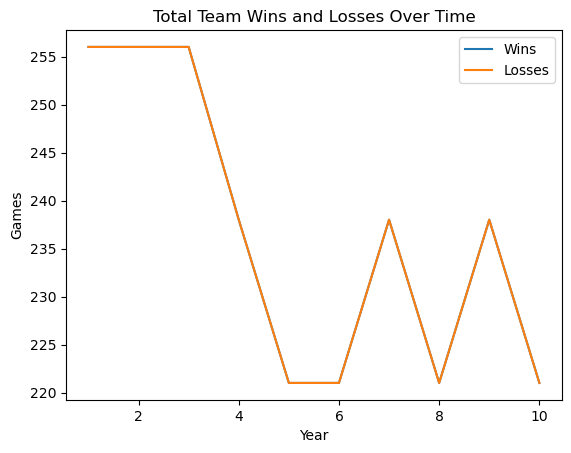

In [24]:
# Team win/loss records over time
team_wins = teams_df.groupby('year')['won'].sum()
team_losses = teams_df.groupby('year')['lost'].sum()

print(team_wins.head())

plt.plot(team_wins.index, team_wins.values, label='Wins')
plt.plot(team_losses.index, team_losses.values, label='Losses')
plt.title('Total Team Wins and Losses Over Time')
plt.xlabel('Year')
plt.ylabel('Games')
plt.legend()
plt.show()

### 10 teams with highest win rate

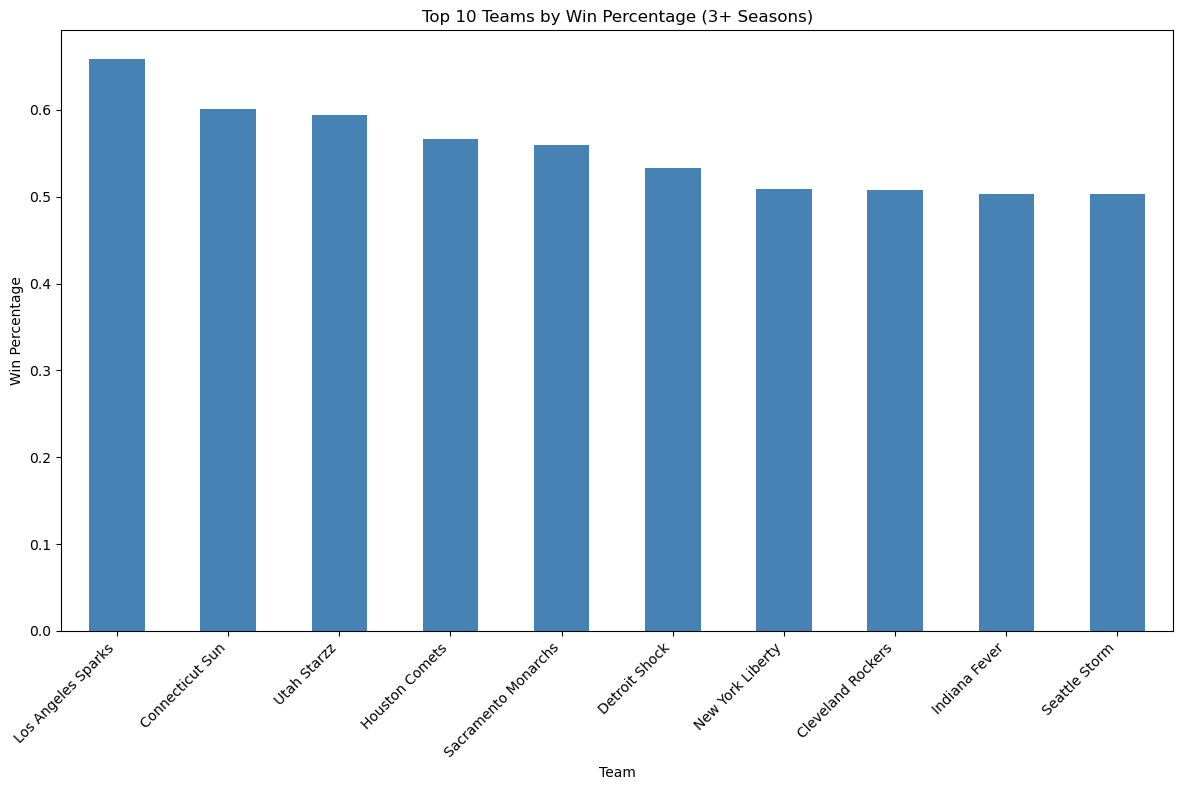

Top performing teams:
                     won  lost  seasons  total_games   win_pct
name                                                          
Los Angeles Sparks   220   114       10          334  0.658683
Connecticut Sun      143    95        7          238  0.600840
Utah Starzz           57    39        3           96  0.593750
Houston Comets       170   130        9          300  0.566667
Sacramento Monarchs  187   147       10          334  0.559880


In [25]:
# Team win percentage over time
teams_df['win_pct'] = teams_df['won'] / (teams_df['won'] + teams_df['lost'])

# Top teams by overall win percentage
team_performance = teams_df.groupby('name').agg({
    'won': 'sum',
    'lost': 'sum',
    'year': 'count'
}).rename(columns={'year': 'seasons'})

team_performance['total_games'] = team_performance['won'] + team_performance['lost']
team_performance['win_pct'] = team_performance['won'] / team_performance['total_games']

# Filter teams with at least 3 seasons
experienced_teams = team_performance[team_performance['seasons'] >= 3].sort_values('win_pct', ascending=False)

plt.figure(figsize=(12, 8))
experienced_teams['win_pct'].head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Teams by Win Percentage (3+ Seasons)')
plt.ylabel('Win Percentage')
plt.xlabel('Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top performing teams:")
print(experienced_teams.head())

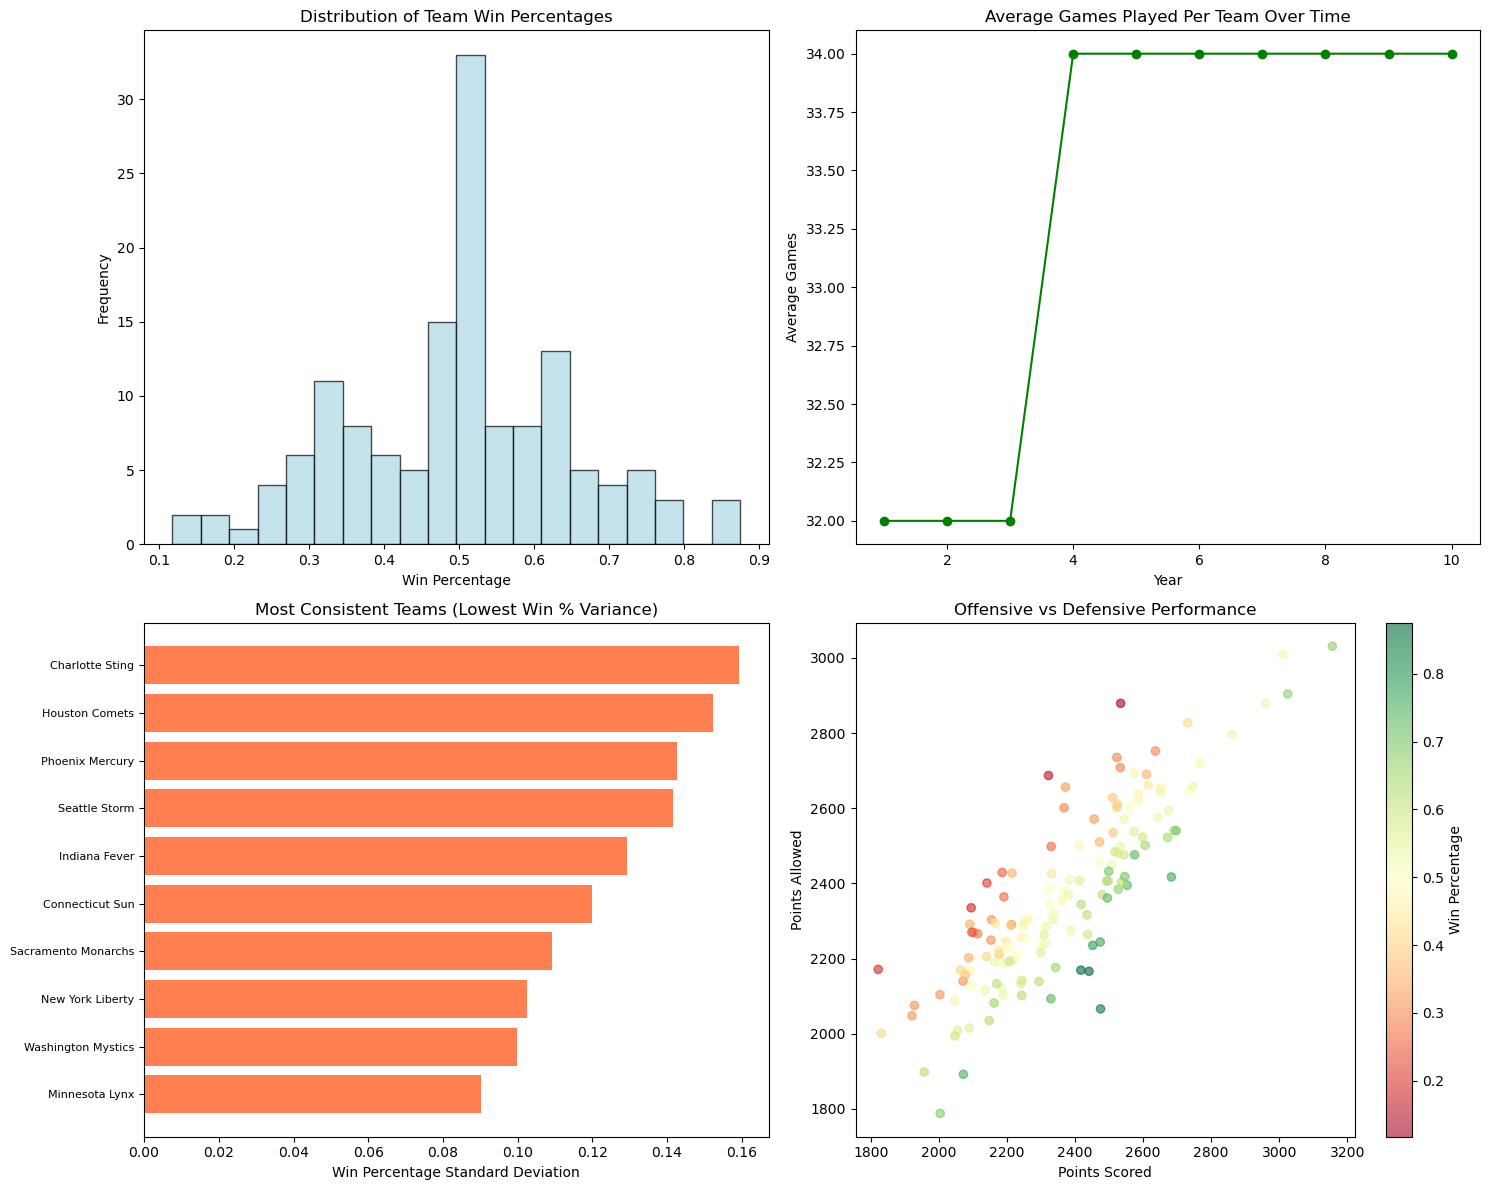

In [26]:
# Team performance consistency over time
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Win percentage distribution
axes[0,0].hist(teams_df['win_pct'], bins=20, alpha=0.7, color='lightblue', edgecolor='black')
axes[0,0].set_title('Distribution of Team Win Percentages')
axes[0,0].set_xlabel('Win Percentage')
axes[0,0].set_ylabel('Frequency')

# Games played over time (to see if schedule changed)
games_per_year = teams_df.groupby('year')['GP'].mean()
axes[0,1].plot(games_per_year.index, games_per_year.values, marker='o', color='green')
axes[0,1].set_title('Average Games Played Per Team Over Time')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Average Games')

# Win percentage variance for teams with multiple seasons
team_variance = teams_df.groupby('name')['win_pct'].agg(['mean', 'std', 'count'])
consistent_teams = team_variance[team_variance['count'] >= 5].sort_values('std')

axes[1,0].barh(range(len(consistent_teams.head(10))), consistent_teams.head(10)['std'], color='coral')
axes[1,0].set_yticks(range(len(consistent_teams.head(10))))
axes[1,0].set_yticklabels(consistent_teams.head(10).index, fontsize=8)
axes[1,0].set_title('Most Consistent Teams (Lowest Win % Variance)')
axes[1,0].set_xlabel('Win Percentage Standard Deviation')

# Points scored vs points allowed
axes[1,1].scatter(teams_df['o_pts'], teams_df['d_pts'], alpha=0.6, c=teams_df['win_pct'], cmap='RdYlGn')
axes[1,1].set_xlabel('Points Scored')
axes[1,1].set_ylabel('Points Allowed')
axes[1,1].set_title('Offensive vs Defensive Performance')
cbar = plt.colorbar(axes[1,1].collections[0], ax=axes[1,1])
cbar.set_label('Win Percentage')

plt.tight_layout()
plt.show()

### Playoff Performance Analysis

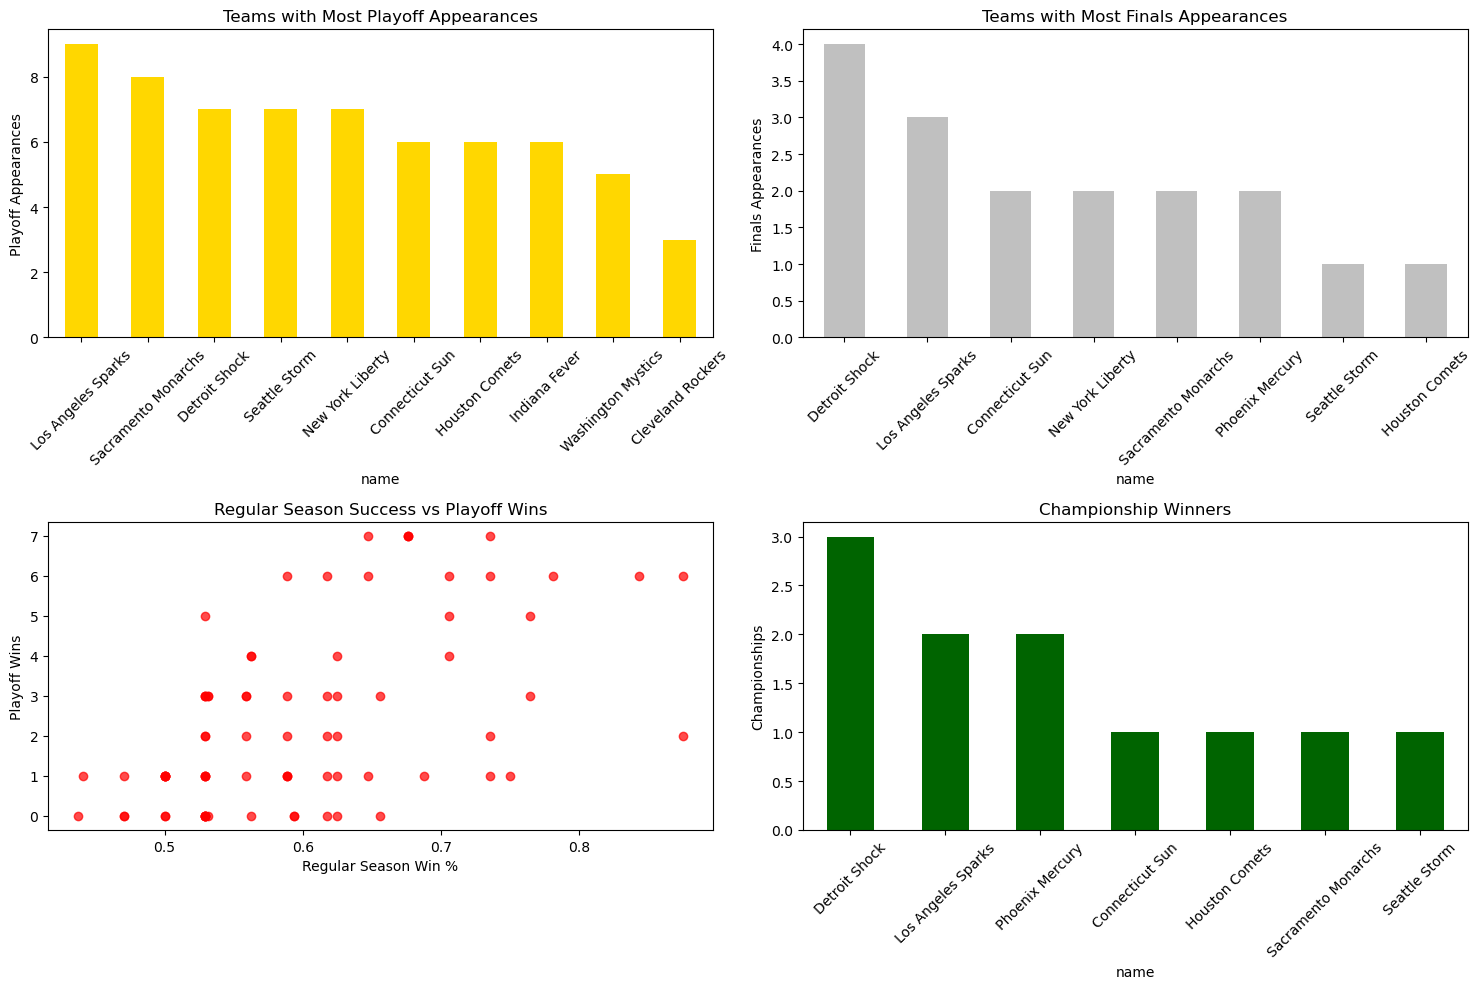

Playoff participation summary:
Total seasons: 142
Playoff appearances: 80
Playoff participation rate: 56.3%


In [27]:
# Playoff participation analysis
playoff_teams = teams_df[teams_df['playoff'] == 'Y']
playoff_participation = teams_df.groupby('name')['playoff'].apply(lambda x: (x == 'Y').sum()).sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Teams with most playoff appearances
playoff_participation.head(10).plot(kind='bar', ax=axes[0,0], color='gold')
axes[0,0].set_title('Teams with Most Playoff Appearances')
axes[0,0].set_ylabel('Playoff Appearances')
axes[0,0].tick_params(axis='x', rotation=45)

# Playoff success rates (finals appearances)
finals_teams = teams_df[teams_df['finals'].notna()]
finals_appearances = teams_df.groupby('name')['finals'].apply(lambda x: x.notna().sum()).sort_values(ascending=False)
finals_appearances[finals_appearances > 0].head(8).plot(kind='bar', ax=axes[0,1], color='silver')
axes[0,1].set_title('Teams with Most Finals Appearances')
axes[0,1].set_ylabel('Finals Appearances')
axes[0,1].tick_params(axis='x', rotation=45)

# Regular season vs playoff performance correlation
if not teams_post_df.empty:
    # Merge regular season and playoff data
    playoff_merged = teams_df.merge(teams_post_df, on=['year', 'tmID'], suffixes=('_reg', '_playoff'))
    if not playoff_merged.empty:
        axes[1,0].scatter(playoff_merged['win_pct'], playoff_merged['W'], alpha=0.7, color='red')
        axes[1,0].set_xlabel('Regular Season Win %')
        axes[1,0].set_ylabel('Playoff Wins')
        axes[1,0].set_title('Regular Season Success vs Playoff Wins')

# Championship winners over time
champions = teams_df[teams_df['finals'] == 'W']
if not champions.empty:
    champion_counts = champions['name'].value_counts()
    champion_counts.plot(kind='bar', ax=axes[1,1], color='darkgreen')
    axes[1,1].set_title('Championship Winners')
    axes[1,1].set_ylabel('Championships')
    axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Playoff participation summary:")
print(f"Total seasons: {len(teams_df)}")
print(f"Playoff appearances: {len(playoff_teams)}")
print(f"Playoff participation rate: {len(playoff_teams)/len(teams_df):.1%}")

### Team Statistics and Performance Correlation

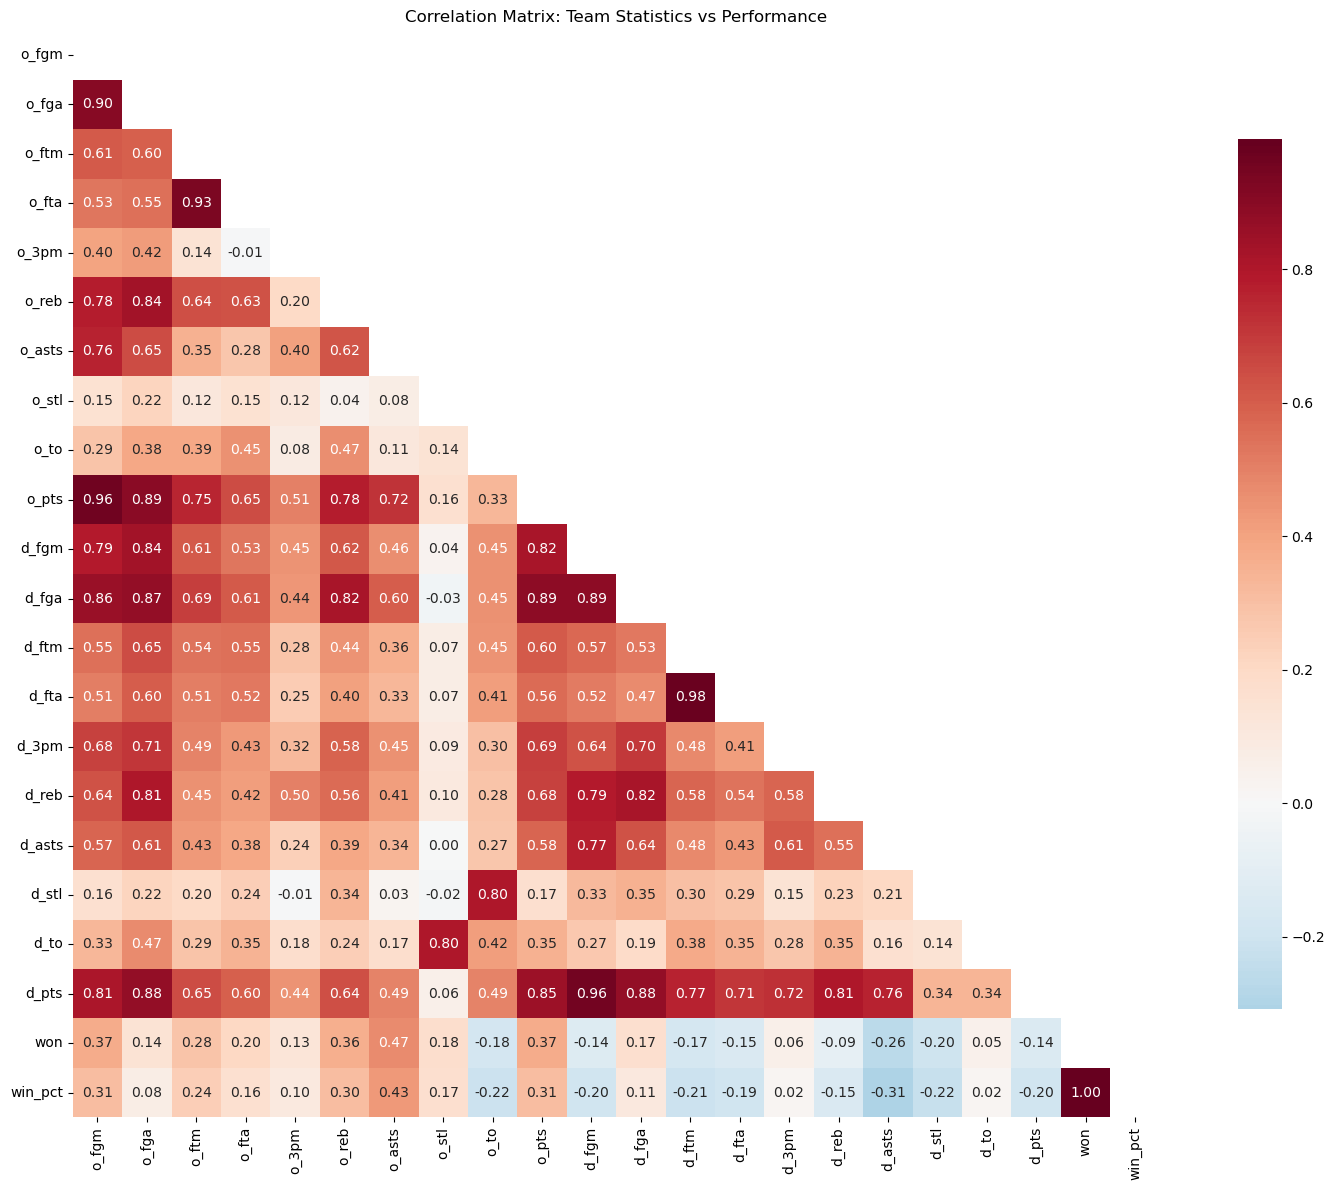

Strongest correlations with win percentage:
won       0.995039
o_asts    0.431768
o_pts     0.311704
o_fgm     0.311432
d_asts   -0.307801
o_reb     0.303479
o_ftm     0.243736
d_stl    -0.223372
o_to     -0.215464
d_ftm    -0.212571
Name: win_pct, dtype: float64


In [ ]:
# Correlation between key statistics and winning
import seaborn as sns

# Select key offensive and defensive statistics
key_stats = ['o_fgm', 'o_fga', 'o_ftm', 'o_fta', 'o_3pm', 'o_reb', 'o_asts', 'o_stl', 'o_to', 'o_pts',
             'd_fgm', 'd_fga', 'd_ftm', 'd_fta', 'd_3pm', 'd_reb', 'd_asts', 'd_stl', 'd_to', 'd_pts',
             'won', 'win_pct']
    
# Create correlation matrix
correlation_matrix = teams_df[key_stats].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix: Team Statistics vs Performance')
plt.tight_layout()
plt.show()

# Show strongest correlations with winning percentage
win_correlations = correlation_matrix['win_pct'].sort_values(key=abs, ascending=False)
print("Strongest correlations with win percentage:")
print(win_correlations[1:11])  # Skip self-correlation

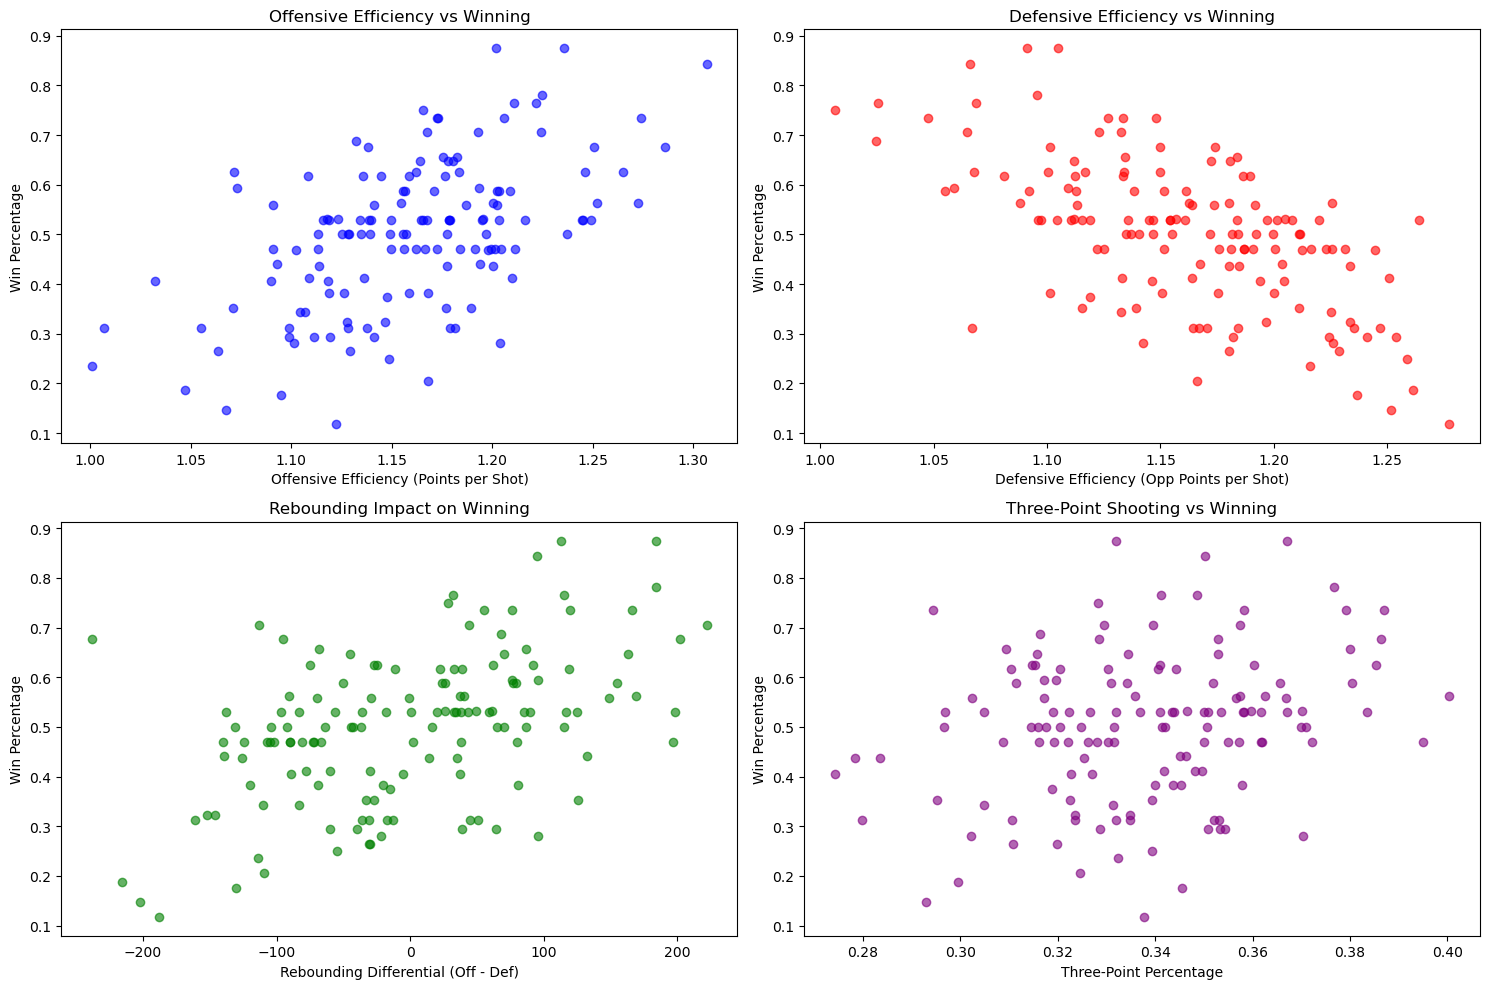

In [29]:
# Offensive vs Defensive efficiency analysis
teams_df['off_efficiency'] = teams_df['o_pts'] / teams_df['o_fga']  # Points per shot attempt
teams_df['def_efficiency'] = teams_df['d_pts'] / teams_df['d_fga']  # Opponent points per their shot attempt
teams_df['turnover_ratio'] = teams_df['o_stl'] / teams_df['o_to']   # Steals vs turnovers

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Offensive efficiency vs win percentage
axes[0,0].scatter(teams_df['off_efficiency'], teams_df['win_pct'], alpha=0.6, color='blue')
axes[0,0].set_xlabel('Offensive Efficiency (Points per Shot)')
axes[0,0].set_ylabel('Win Percentage')
axes[0,0].set_title('Offensive Efficiency vs Winning')

# Defensive efficiency vs win percentage (lower is better for defense)
axes[0,1].scatter(teams_df['def_efficiency'], teams_df['win_pct'], alpha=0.6, color='red')
axes[0,1].set_xlabel('Defensive Efficiency (Opp Points per Shot)')
axes[0,1].set_ylabel('Win Percentage')
axes[0,1].set_title('Defensive Efficiency vs Winning')

# Rebounding analysis
teams_df['reb_diff'] = teams_df['o_reb'] - teams_df['d_reb']
axes[1,0].scatter(teams_df['reb_diff'], teams_df['win_pct'], alpha=0.6, color='green')
axes[1,0].set_xlabel('Rebounding Differential (Off - Def)')
axes[1,0].set_ylabel('Win Percentage')
axes[1,0].set_title('Rebounding Impact on Winning')

# Three-point shooting analysis
teams_df['three_pct'] = teams_df['o_3pm'] / teams_df['o_3pa']
teams_df['opp_three_pct'] = teams_df['d_3pm'] / teams_df['d_3pa']
axes[1,1].scatter(teams_df['three_pct'], teams_df['win_pct'], alpha=0.6, color='purple')
axes[1,1].set_xlabel('Three-Point Percentage')
axes[1,1].set_ylabel('Win Percentage')
axes[1,1].set_title('Three-Point Shooting vs Winning')

plt.tight_layout()
plt.show()

### Conference and Division Analysis

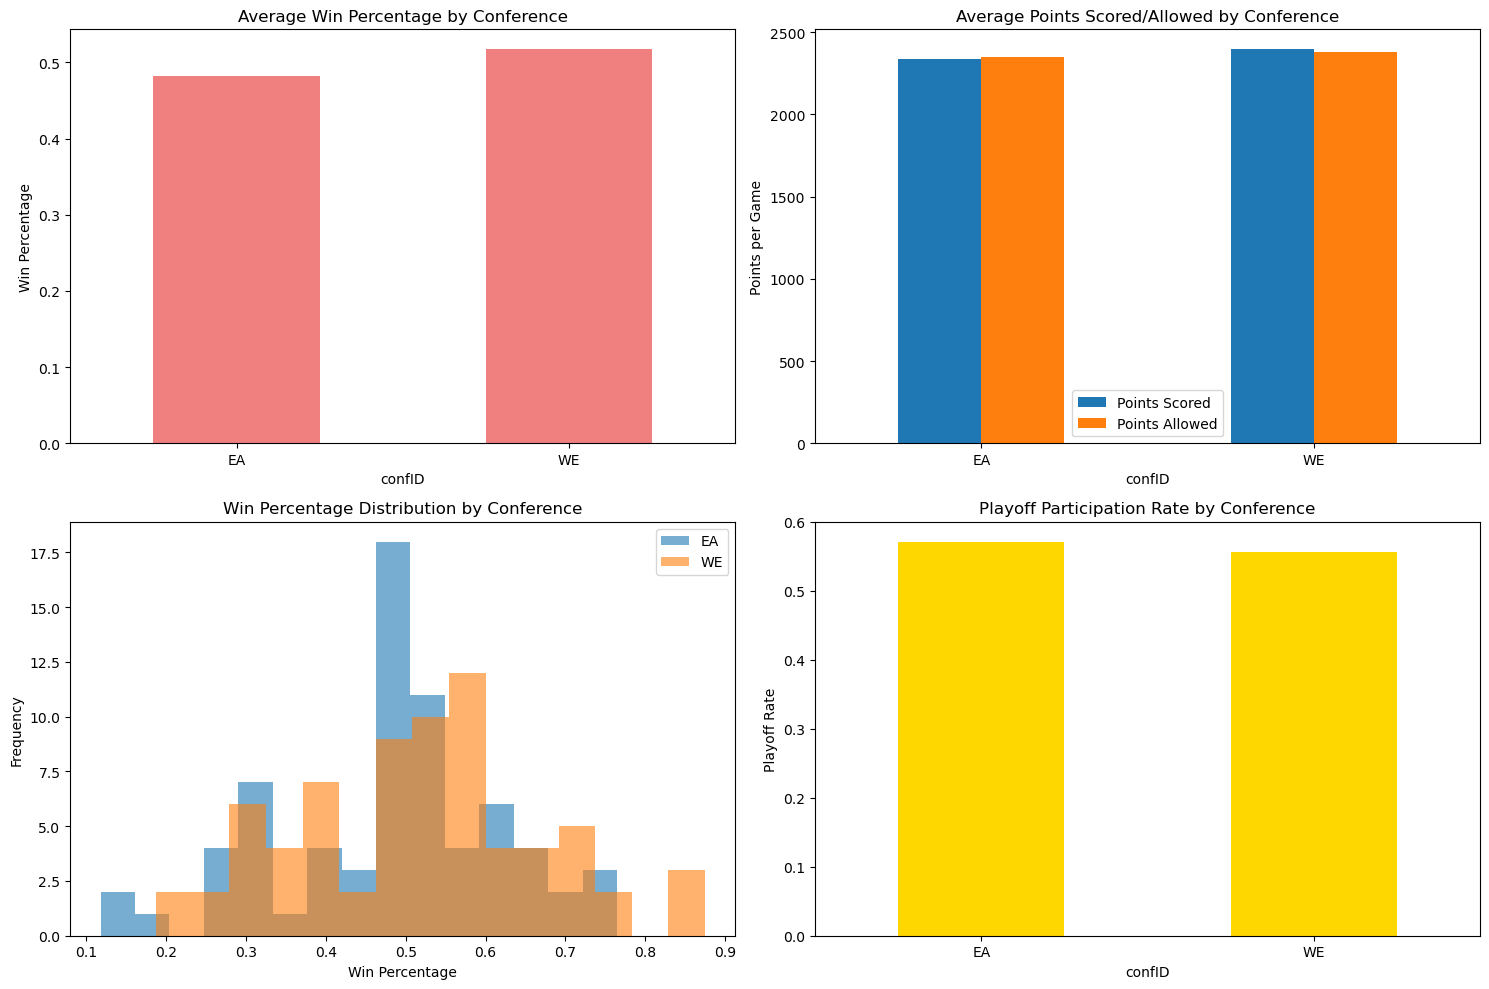

Conference performance summary:
         win_pct        o_pts        d_pts  team_seasons
confID                                                  
EA      0.481985  2334.171429  2350.885714            70
WE      0.517514  2397.486111  2381.208333            72


In [30]:
# Conference performance comparison
conference_performance = teams_df.groupby('confID').agg({
    'win_pct': 'mean',
    'o_pts': 'mean',
    'd_pts': 'mean',
    'year': 'count'
}).rename(columns={'year': 'team_seasons'})

conference_performance = conference_performance[conference_performance['team_seasons'] > 10]  # Filter for significance

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Conference win percentages
conference_performance['win_pct'].plot(kind='bar', ax=axes[0,0], color='lightcoral')
axes[0,0].set_title('Average Win Percentage by Conference')
axes[0,0].set_ylabel('Win Percentage')
axes[0,0].tick_params(axis='x', rotation=0)

# Conference scoring
conference_performance[['o_pts', 'd_pts']].plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Average Points Scored/Allowed by Conference')
axes[0,1].set_ylabel('Points per Game')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(['Points Scored', 'Points Allowed'])

# Competitive balance - win percentage distribution by conference
for i, conf in enumerate(teams_df['confID'].unique()):
    if pd.notna(conf) and conf != '':
        conf_data = teams_df[teams_df['confID'] == conf]['win_pct']
        if len(conf_data) > 5:  # Only if enough data
            axes[1,0].hist(conf_data, alpha=0.6, label=conf, bins=15)

axes[1,0].set_title('Win Percentage Distribution by Conference')
axes[1,0].set_xlabel('Win Percentage')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# Playoff success by conference
conference_playoffs = teams_df[teams_df['playoff'] == 'Y'].groupby('confID').size()
conference_total = teams_df.groupby('confID').size()
playoff_rate = (conference_playoffs / conference_total).dropna()

playoff_rate.plot(kind='bar', ax=axes[1,1], color='gold')
axes[1,1].set_title('Playoff Participation Rate by Conference')
axes[1,1].set_ylabel('Playoff Rate')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Conference performance summary:")
print(conference_performance)

### Home vs Away Performance

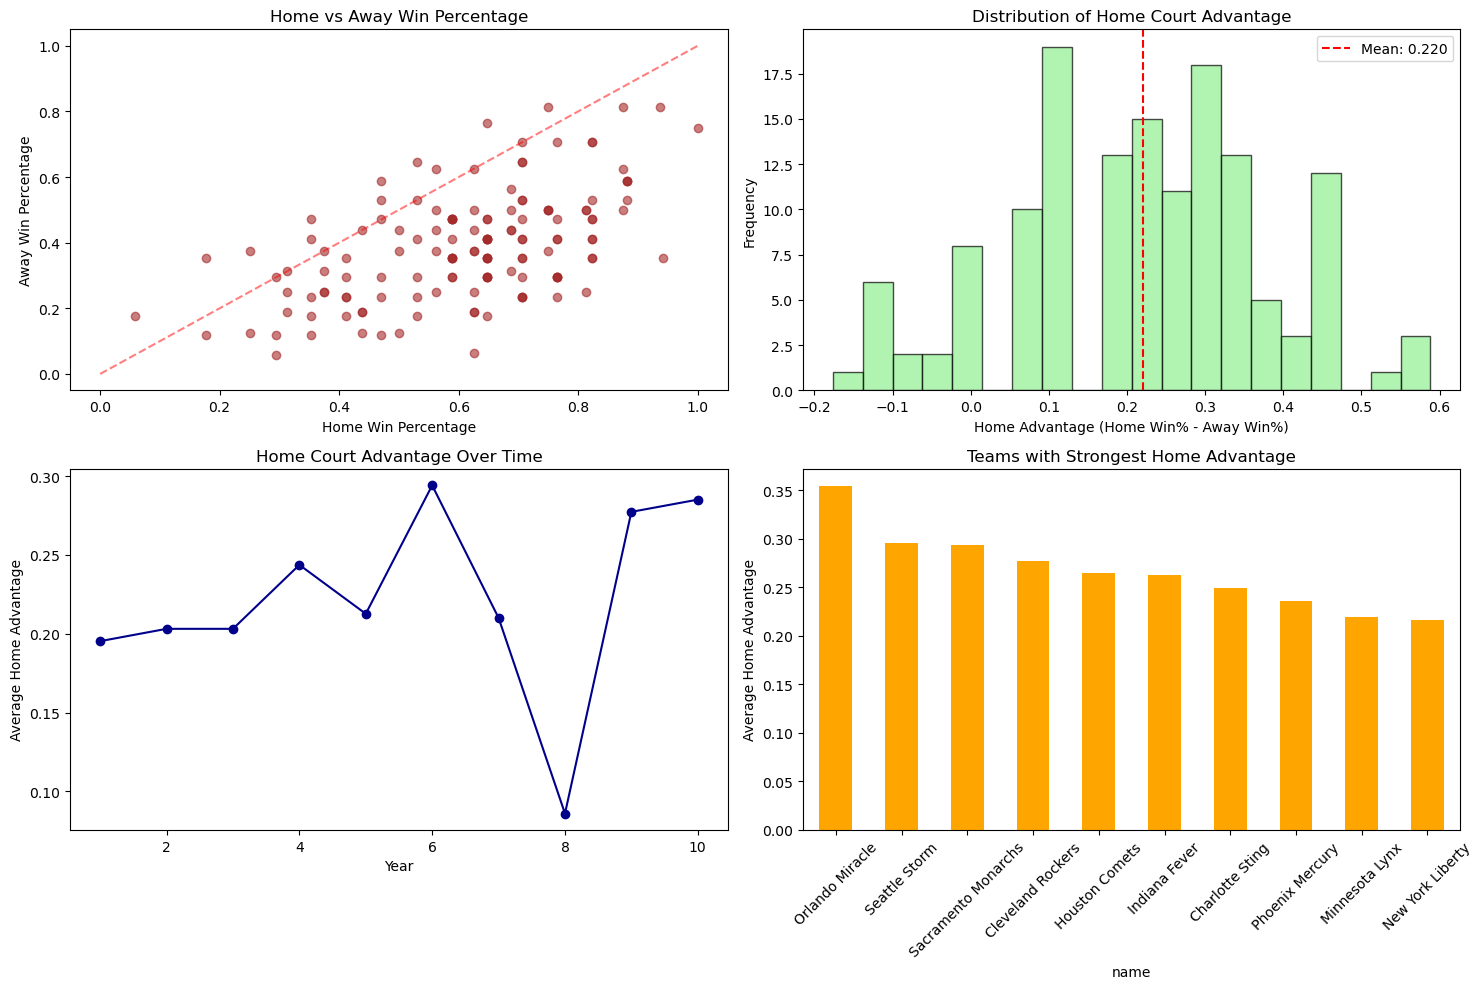

League average home court advantage: 0.220
Home win percentage: 0.610
Away win percentage: 0.390


In [31]:
# Home court advantage analysis
teams_df['home_win_pct'] = teams_df['homeW'] / (teams_df['homeW'] + teams_df['homeL'])
teams_df['away_win_pct'] = teams_df['awayW'] / (teams_df['awayW'] + teams_df['awayL'])
teams_df['home_advantage'] = teams_df['home_win_pct'] - teams_df['away_win_pct']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Home vs Away win percentage scatter
axes[0,0].scatter(teams_df['home_win_pct'], teams_df['away_win_pct'], alpha=0.6, color='brown')
axes[0,0].plot([0, 1], [0, 1], 'r--', alpha=0.5)  # Diagonal line for reference
axes[0,0].set_xlabel('Home Win Percentage')
axes[0,0].set_ylabel('Away Win Percentage')
axes[0,0].set_title('Home vs Away Win Percentage')

# Home advantage distribution
axes[0,1].hist(teams_df['home_advantage'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].axvline(teams_df['home_advantage'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {teams_df["home_advantage"].mean():.3f}')
axes[0,1].set_xlabel('Home Advantage (Home Win% - Away Win%)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Home Court Advantage')
axes[0,1].legend()

# Home advantage over time
home_adv_by_year = teams_df.groupby('year')['home_advantage'].mean()
axes[1,0].plot(home_adv_by_year.index, home_adv_by_year.values, marker='o', color='darkblue')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Average Home Advantage')
axes[1,0].set_title('Home Court Advantage Over Time')

# Teams with strongest home advantage
top_home_teams = teams_df.groupby('name')['home_advantage'].mean().sort_values(ascending=False)
top_home_teams.head(10).plot(kind='bar', ax=axes[1,1], color='orange')
axes[1,1].set_title('Teams with Strongest Home Advantage')
axes[1,1].set_ylabel('Average Home Advantage')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"League average home court advantage: {teams_df['home_advantage'].mean():.3f}")
print(f"Home win percentage: {teams_df['home_win_pct'].mean():.3f}")
print(f"Away win percentage: {teams_df['away_win_pct'].mean():.3f}")

### Attendance and Team Performance

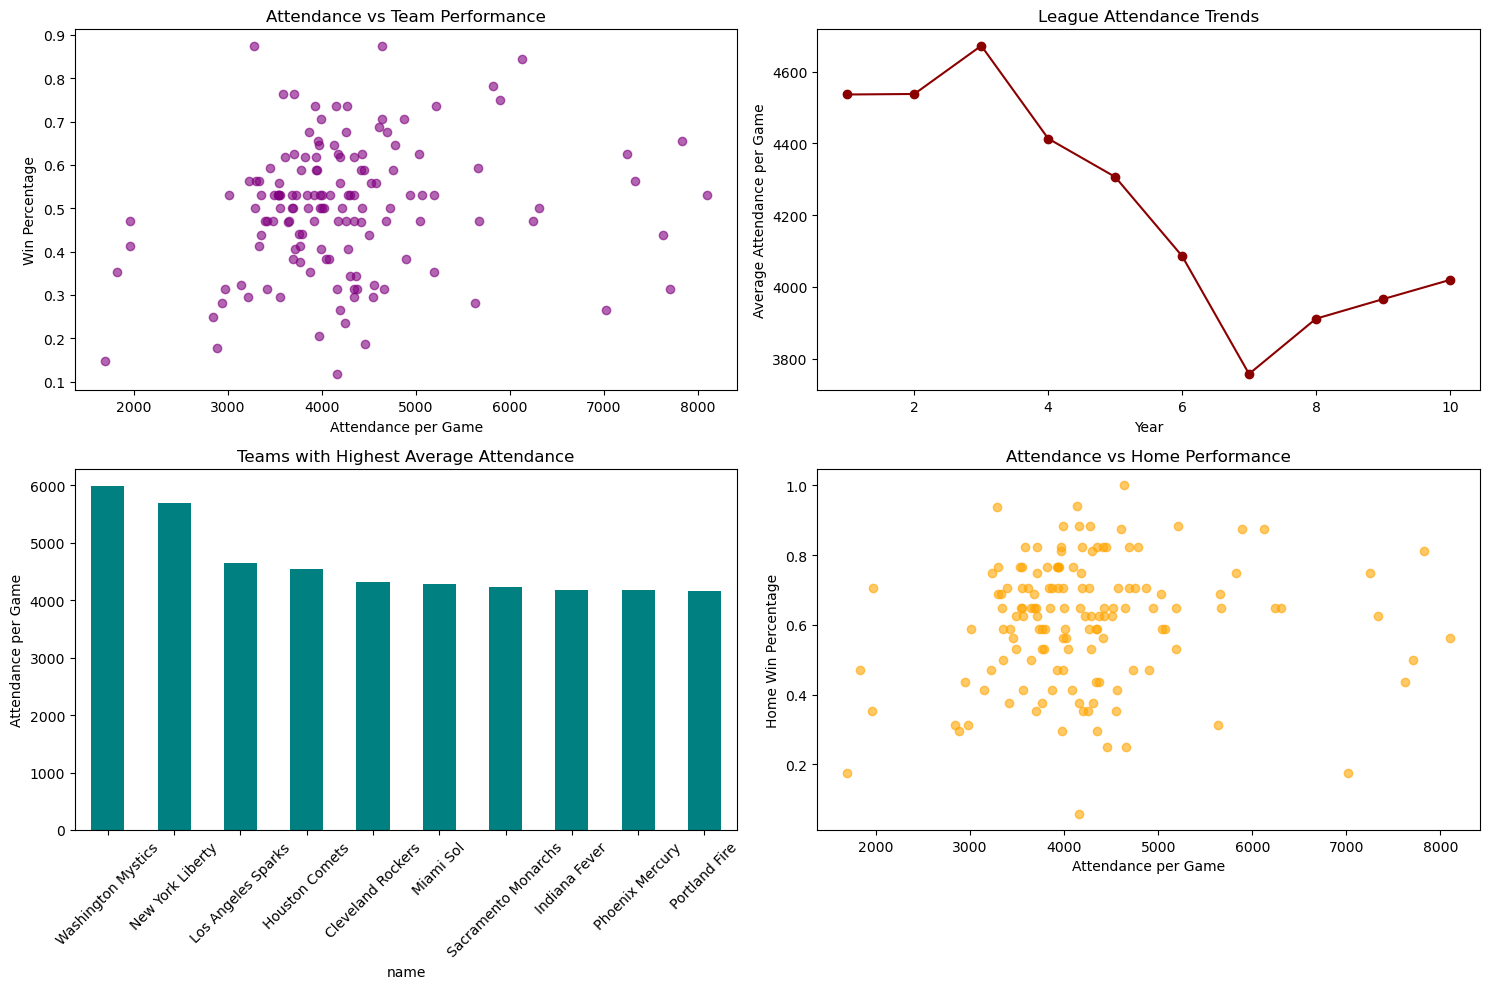

Attendance correlations:
attendance_per_game    1.000000
win_pct                0.172640
home_win_pct           0.108801
Name: attendance_per_game, dtype: float64


In [32]:
# Attendance analysis
# Calculate attendance per game
teams_df['attendance_per_game'] = teams_df['attend'] / teams_df['GP']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Attendance vs Win Percentage
axes[0,0].scatter(teams_df['attendance_per_game'], teams_df['win_pct'], alpha=0.6, color='purple')
axes[0,0].set_xlabel('Attendance per Game')
axes[0,0].set_ylabel('Win Percentage')
axes[0,0].set_title('Attendance vs Team Performance')

# Attendance trends over time
attendance_by_year = teams_df.groupby('year')['attendance_per_game'].mean()
axes[0,1].plot(attendance_by_year.index, attendance_by_year.values, marker='o', color='darkred')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Average Attendance per Game')
axes[0,1].set_title('League Attendance Trends')

# Top teams by attendance
top_attendance = teams_df.groupby('name')['attendance_per_game'].mean().sort_values(ascending=False)
top_attendance.head(10).plot(kind='bar', ax=axes[1,0], color='teal')
axes[1,0].set_title('Teams with Highest Average Attendance')
axes[1,0].set_ylabel('Attendance per Game')
axes[1,0].tick_params(axis='x', rotation=45)

# Attendance vs Home Win Percentage
axes[1,1].scatter(teams_df['attendance_per_game'], teams_df['home_win_pct'], alpha=0.6, color='orange')
axes[1,1].set_xlabel('Attendance per Game')
axes[1,1].set_ylabel('Home Win Percentage')
axes[1,1].set_title('Attendance vs Home Performance')

plt.tight_layout()
plt.show()

# Calculate correlation between attendance and performance
attendance_correlation = teams_df[['attendance_per_game', 'win_pct', 'home_win_pct']].corr()
print("Attendance correlations:")
print(attendance_correlation['attendance_per_game'].sort_values(ascending=False))